# TP Module 2 — RNN, LSTM & GRU pour séries temporelles

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

À l'issue de ce TP, vous serez capable de :

1. Comprendre les **équations** du RNN vanille, du LSTM et du GRU et le phénomène de **vanishing gradient**
2. Implémenter ces 3 architectures en PyTorch via `nn.RNN`, `nn.LSTM`, `nn.GRU`
3. Maîtriser les **séquences de longueur variable** (`pack_padded_sequence`) et le **gradient clipping**
4. Construire un BiLSTM (`bidirectional=True`) et comprendre ses avantages
5. Appliquer ces modèles à **3 tâches canoniques** de séries temporelles :
   - **Classification** d'activité humaine (UCI HAR Dataset — accéléromètre 3 axes)
   - **Forecasting** multi-step (ETT — Electricity Transformer Temperature)
   - **Détection d'anomalies** sur capteurs industriels (AI4I 2020 Predictive Maintenance)
6. Évaluer chaque modèle avec les métriques appropriées (Accuracy/F1, MAE/RMSE/MAPE, AUC-ROC/F1)

## Pré-requis

- TP du Module 1 (PyTorch, MLP, CNN)
- Bibliothèques : `torch`, `numpy`, `pandas`, `matplotlib`, `scikit-learn`

## Datasets

Les 3 datasets utilisés sont **téléchargés automatiquement** depuis leurs sources officielles dans la cellule d'initialisation ci-dessous :

| Tâche | Dataset | Source | Taille |
|---|---|---|---|
| Classification | UCI HAR | archive.ics.uci.edu | ~60 MB |
| Forecasting | ETTh1 | github.com/zhouhaoyi/ETDataset | ~2 MB |
| Détection d'anomalies | AI4I 2020 | archive.ics.uci.edu | ~0.5 MB |


## Partie I — Rappels théoriques

### I.1 Le RNN vanille — récurrence dans le temps

Soit une séquence d'entrée $\mathbf{x}_{1:T} = (\mathbf{x}_1, \dots, \mathbf{x}_T)$ avec $\mathbf{x}_t \in \mathbb{R}^d$.
Un **RNN** maintient un **état caché** $\mathbf{h}_t \in \mathbb{R}^H$ qui résume tout l'historique jusqu'à $t$ :

$$
\boxed{\;\mathbf{h}_t = \tanh\!\bigl(\mathbf{W}_{xh}\,\mathbf{x}_t + \mathbf{W}_{hh}\,\mathbf{h}_{t-1} + \mathbf{b}_h\bigr)\;}
$$

avec :
- $\mathbf{W}_{xh} \in \mathbb{R}^{H \times d}$ — matrice entrée → caché
- $\mathbf{W}_{hh} \in \mathbb{R}^{H \times H}$ — matrice caché → caché (récurrence)
- $\mathbf{b}_h \in \mathbb{R}^{H}$ — biais
- $\mathbf{h}_0 = \mathbf{0}$ (ou appris)

La sortie à chaque pas :
$$
\mathbf{y}_t = \mathbf{W}_{hy}\,\mathbf{h}_t + \mathbf{b}_y
$$

**Backpropagation Through Time (BPTT)** : on déroule le réseau sur $T$ pas et on applique la chain rule. Pour un loss $\mathcal{L} = \sum_t \mathcal{L}_t$ :

$$
\frac{\partial \mathcal{L}_T}{\partial \mathbf{h}_t} = \frac{\partial \mathcal{L}_T}{\partial \mathbf{h}_T} \cdot \prod_{k=t+1}^{T} \frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}}
$$

avec
$$
\frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} = \operatorname{diag}\!\bigl(\tanh'(\cdot)\bigr) \cdot \mathbf{W}_{hh}
$$

### I.2 Le problème du gradient vanishing / exploding

Le produit de $T-t$ jacobiens $\frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}}$ engendre une dynamique de **valeurs singulières** :

$$
\Bigl\Vert \prod_{k=t+1}^{T} \frac{\partial \mathbf{h}_k}{\partial \mathbf{h}_{k-1}} \Bigr\Vert \lesssim \sigma_{\max}(\mathbf{W}_{hh})^{T-t}
$$

- Si $\sigma_{\max}(\mathbf{W}_{hh}) < 1 \Rightarrow$ **vanishing gradient** : les dépendances long terme sont oubliées (signal $\to 0$)
- Si $\sigma_{\max}(\mathbf{W}_{hh}) > 1 \Rightarrow$ **exploding gradient** : l'optimisation diverge (NaN)

Les architectures **LSTM** et **GRU** résolvent le premier problème via des **portes** ; le second est atténué par **gradient clipping**.


### I.3 LSTM — Long Short-Term Memory (Hochreiter & Schmidhuber, 1997)

Le LSTM introduit un **cell state** $\mathbf{c}_t$ qui circule presque linéairement à travers le temps (highway gradient) et 3 portes qui contrôlent l'information :

| Porte | Symbole | Rôle |
|---|---|---|
| Forget | $\mathbf{f}_t$ | Quoi oublier de $\mathbf{c}_{t-1}$ |
| Input | $\mathbf{i}_t$ | Quoi écrire dans $\mathbf{c}_t$ |
| Output | $\mathbf{o}_t$ | Quoi exposer dans $\mathbf{h}_t$ |

**Équations LSTM** (toutes les portes prennent $[\mathbf{x}_t; \mathbf{h}_{t-1}]$ en entrée) :

$$
\begin{aligned}
\mathbf{f}_t &= \sigma\bigl(\mathbf{W}_f [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_f\bigr) && \text{(forget gate)} \\
\mathbf{i}_t &= \sigma\bigl(\mathbf{W}_i [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_i\bigr) && \text{(input gate)} \\
\tilde{\mathbf{c}}_t &= \tanh\bigl(\mathbf{W}_c [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_c\bigr) && \text{(candidate cell)} \\
\boxed{\;\mathbf{c}_t} &\boxed{\;= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t\;} && \text{(cell state update)} \\
\mathbf{o}_t &= \sigma\bigl(\mathbf{W}_o [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_o\bigr) && \text{(output gate)} \\
\boxed{\;\mathbf{h}_t} &\boxed{\;= \mathbf{o}_t \odot \tanh(\mathbf{c}_t)\;} && \text{(hidden state)}
\end{aligned}
$$

avec $\sigma(\cdot)$ la sigmoïde, $\odot$ le produit de Hadamard (élément par élément).

**Pourquoi le LSTM règle le vanishing gradient ?**
La récurrence sur $\mathbf{c}_t$ est **additive** :
$$
\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_{t-1}} = \operatorname{diag}(\mathbf{f}_t)
$$
Quand $\mathbf{f}_t \approx \mathbf{1}$, le gradient se propage sans décroître — c'est le **constant error carousel** (CEC).

**Nombre de paramètres** d'une couche LSTM (input $d$, hidden $H$) :
$$
P_{\text{LSTM}} = 4 \times H \times (d + H + 1)
$$
(4 jeux $\{W_f, W_i, W_c, W_o\}$, chacun de taille $H \times (d+H)$ plus biais $H$.)


### I.4 GRU — Gated Recurrent Unit (Cho et al., 2014)

Le GRU fusionne le cell state et l'hidden state, et n'utilise que **2 portes** : **reset** et **update**.

$$
\begin{aligned}
\mathbf{z}_t &= \sigma\bigl(\mathbf{W}_z [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_z\bigr) && \text{(update gate)} \\
\mathbf{r}_t &= \sigma\bigl(\mathbf{W}_r [\mathbf{x}_t; \mathbf{h}_{t-1}] + \mathbf{b}_r\bigr) && \text{(reset gate)} \\
\tilde{\mathbf{h}}_t &= \tanh\bigl(\mathbf{W}_h [\mathbf{x}_t; \mathbf{r}_t \odot \mathbf{h}_{t-1}] + \mathbf{b}_h\bigr) && \text{(candidate)} \\
\boxed{\;\mathbf{h}_t} &\boxed{\;= (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t\;} && \text{(hidden state)}
\end{aligned}
$$

**Comparaison LSTM vs GRU** :

| Critère | LSTM | GRU |
|---|---|---|
| Portes | 3 (forget, input, output) | 2 (reset, update) |
| États | $(\mathbf{h}_t, \mathbf{c}_t)$ | $\mathbf{h}_t$ uniquement |
| Paramètres | $4H(d+H+1)$ | $3H(d+H+1)$ |
| Quand préférer | Séquences longues, signal fort à retenir | Datasets plus petits, vitesse de convergence |
| Performance | Souvent ~égales en pratique | ~25 % plus rapide |

### I.5 RNN bidirectionnel (BiLSTM, BiGRU)

Un BiLSTM combine deux LSTM, l'un parcourant la séquence dans le sens **temporel** $(1 \to T)$, l'autre dans le sens **anti-temporel** $(T \to 1)$ :

$$
\overrightarrow{\mathbf{h}}_t = \text{LSTM}_{\rightarrow}(\mathbf{x}_t, \overrightarrow{\mathbf{h}}_{t-1}), \quad
\overleftarrow{\mathbf{h}}_t = \text{LSTM}_{\leftarrow}(\mathbf{x}_t, \overleftarrow{\mathbf{h}}_{t+1}), \quad
\mathbf{h}_t = [\overrightarrow{\mathbf{h}}_t ; \overleftarrow{\mathbf{h}}_t] \in \mathbb{R}^{2H}
$$

**Cas d'usage** : tâches **offline** où le contexte futur est disponible (classification de séquence complète, détection d'anomalies a posteriori).
**Contre-indication** : forecasting temps réel — le futur n'est pas observable.

### I.6 Gradient clipping

Pour éviter les **gradients explosifs**, on borne la norme globale du gradient :

$$
\mathbf{g} \leftarrow \min\!\left(1,\; \frac{\tau}{\Vert \mathbf{g} \Vert_2}\right) \cdot \mathbf{g}
$$

avec $\tau$ le seuil (typiquement $\tau = 1.0$ ou $5.0$). En PyTorch :
```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

### I.7 Métriques par tâche

| Tâche | Métriques | Formule clé |
|---|---|---|
| Classification | Accuracy, F1 (macro), Confusion Matrix | $F_1 = 2 \cdot \frac{P \cdot R}{P+R}$ |
| Forecasting | MAE, RMSE, MAPE | $\text{RMSE} = \sqrt{\tfrac{1}{N}\sum (y - \hat y)^2}$ |
| Détection d'anomalies | AUC-ROC, F1, Precision/Recall | TPR/FPR sur seuils |


## Partie II — Setup et imports

In [3]:
import os
import io
import ssl
import zipfile
import urllib.request
import urllib.error
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error,
    roc_auc_score, precision_recall_fscore_support,
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                     ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Device utilisé : {DEVICE}")

DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)
print(f"Dossier de données : {DATA_DIR.resolve()}")

# --- Helper de téléchargement robuste au problème de certificats SSL expirés ---
# Stratégie : on essaie d'abord avec certifi (CA bundle à jour). Si une erreur SSL
# survient (CA expirée, horloge système décalée, etc.), on retombe automatiquement
# sur un contexte non vérifié — acceptable ici car les datasets sont publics.
def _build_ctx(verify=True):
    if not verify:
        return ssl._create_unverified_context()
    try:
        import certifi
        return ssl.create_default_context(cafile=certifi.where())
    except ImportError:
        return ssl.create_default_context()

def _download_once(url, dest, ctx):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, context=ctx, timeout=60) as resp, open(dest, "wb") as f:
        while True:
            chunk = resp.read(1 << 16)
            if not chunk:
                break
            f.write(chunk)
    return dest

def safe_urlretrieve(url, dest):
    # 1er essai : vérification SSL standard via certifi
    try:
        return _download_once(url, dest, _build_ctx(verify=True))
    except (ssl.SSLError, urllib.error.URLError) as e:
        msg = str(e)
        if "CERTIFICATE" in msg.upper() or "SSL" in msg.upper():
            print(f"  ⚠️  SSL vérifié a échoué ({msg.splitlines()[0]})")
            print("      → fallback sur contexte non vérifié.")
            return _download_once(url, dest, _build_ctx(verify=False))
        raise

Device utilisé : mps
Dossier de données : /Users/bassembenhamed/Desktop/DL_PyTorch/tp/module_2/data


---

## Partie A — Classification d'activité humaine (UCI HAR)

### A.1 Présentation du dataset

Le **UCI Human Activity Recognition** Dataset (Anguita et al., 2013) contient des enregistrements **accéléromètre + gyroscope** (smartphone Samsung Galaxy S II porté à la taille) de **30 sujets** effectuant **6 activités** :

1. WALKING
2. WALKING_UPSTAIRS
3. WALKING_DOWNSTAIRS
4. SITTING
5. STANDING
6. LAYING

**Format brut** :
- 9 canaux capteurs (accéléromètre body 3D + total 3D + gyroscope 3D)
- Fenêtres glissantes de **128 pas** (2.56 s à 50 Hz)
- 7 352 séquences en train, 2 947 en test
- Tenseur d'entrée par séquence : $\mathbf{X} \in \mathbb{R}^{128 \times 9}$

**Tâche** : classifier la séquence complète $\mathbf{x}_{1:128}$ en une des 6 classes via $\mathbf{h}_T$ (last hidden state) suivi d'une couche linéaire.


In [4]:
# Téléchargement automatique UCI HAR
HAR_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
HAR_DIR = DATA_DIR / "UCI_HAR"

def download_har():
    if (HAR_DIR / "train" / "X_train.txt").exists():
        print("UCI HAR déjà présent.")
        return
    HAR_DIR.mkdir(exist_ok=True)
    outer_zip = HAR_DIR / "har.zip"
    print(f"Téléchargement depuis {HAR_URL} ...")
    safe_urlretrieve(HAR_URL, outer_zip)
    print(f"  → {outer_zip.stat().st_size / 1e6:.1f} MB")
    with zipfile.ZipFile(outer_zip, "r") as z:
        z.extractall(HAR_DIR)
    # L'archive contient un second ZIP "UCI HAR Dataset.zip"
    inner_zip = HAR_DIR / "UCI HAR Dataset.zip"
    if inner_zip.exists():
        with zipfile.ZipFile(inner_zip, "r") as z:
            z.extractall(HAR_DIR)
        # Déplacer le contenu vers HAR_DIR
        src = HAR_DIR / "UCI HAR Dataset"
        for item in src.iterdir():
            item.rename(HAR_DIR / item.name)
        src.rmdir()
    outer_zip.unlink(missing_ok=True)
    print("Extraction terminée.")

download_har()
print("Contenu :", sorted(p.name for p in HAR_DIR.iterdir()))


Téléchargement depuis https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip ...
  ⚠️  SSL vérifié a échoué (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1010)>)
      → fallback sur contexte non vérifié.
  → 61.0 MB
Extraction terminée.
Contenu : ['.DS_Store', 'README.txt', 'UCI HAR Dataset.names', 'UCI HAR Dataset.zip', '__MACOSX', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


In [5]:
# Chargement des signaux bruts (9 canaux × 128 timesteps)
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(split):
    # split ∈ {'train','test'}.  Renvoie X[N,128,9] et y[N].
    base = HAR_DIR / split / "Inertial Signals"
    arrs = []
    for name in SIGNAL_NAMES:
        f = base / f"{name}_{split}.txt"
        arrs.append(np.loadtxt(f))           # [N, 128]
    X = np.stack(arrs, axis=-1)              # [N, 128, 9]
    y = np.loadtxt(HAR_DIR / split / f"y_{split}.txt").astype(int) - 1   # 0..5
    return X.astype(np.float32), y

X_train, y_train = load_signals("train")
X_test,  y_test  = load_signals("test")

CLASSES = ["WALKING", "WALK_UP", "WALK_DOWN", "SITTING", "STANDING", "LAYING"]
print(f"X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape},  y_test  : {y_test.shape}")
print(f"Classes : {dict(zip(*np.unique(y_train, return_counts=True)))}")


X_train : (7352, 128, 9), y_train : (7352,)
X_test  : (2947, 128, 9),  y_test  : (2947,)
Classes : {0: 1226, 1: 1073, 2: 986, 3: 1286, 4: 1374, 5: 1407}


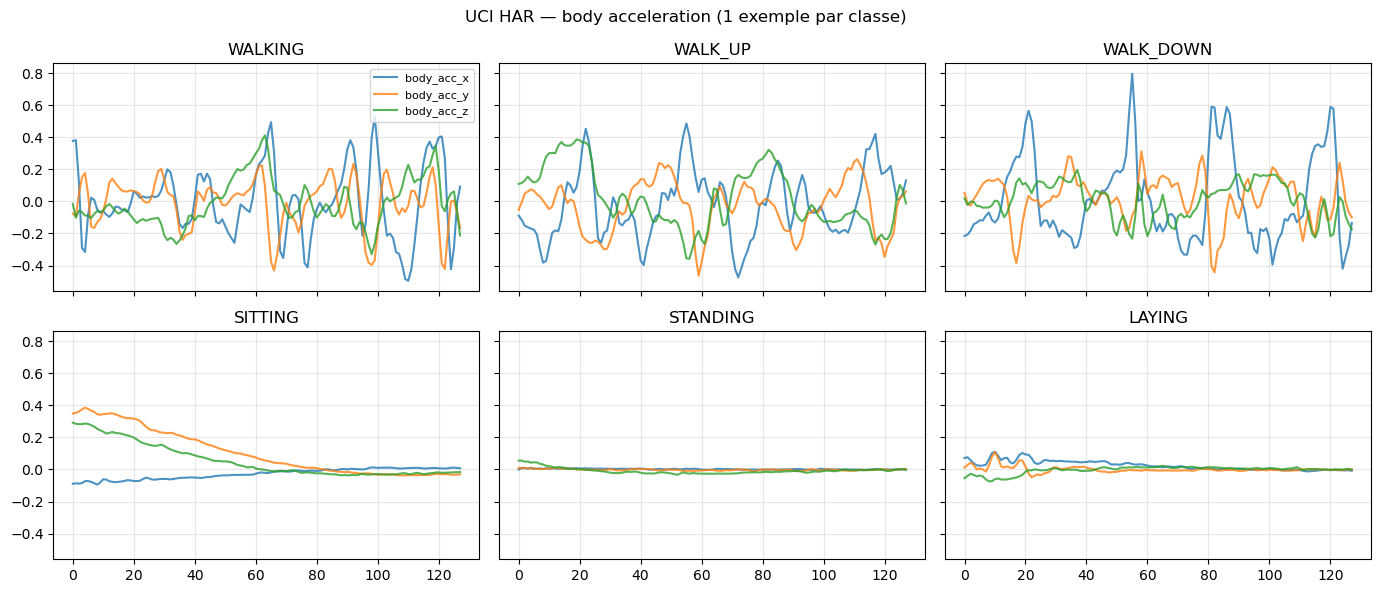

In [6]:
# Visualisation d'une séquence par classe
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True, sharey=True)
for cls in range(6):
    idx = np.where(y_train == cls)[0][0]
    ax = axes[cls // 3, cls % 3]
    for c in range(3):  # juste body_acc_{x,y,z}
        ax.plot(X_train[idx, :, c], label=SIGNAL_NAMES[c], alpha=0.8)
    ax.set_title(CLASSES[cls])
    ax.grid(alpha=0.3)
    if cls == 0:
        ax.legend(fontsize=8, loc="upper right")
fig.suptitle("UCI HAR — body acceleration (1 exemple par classe)")
fig.tight_layout()
plt.show()


In [7]:
# Standardisation par canal (sur le train), Dataset + DataLoader
# On aplatit le temps pour fitter le scaler, puis on remet en (N,T,C)
N_TR, T, C = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, C))
X_train_s = scaler.transform(X_train.reshape(-1, C)).reshape(N_TR, T, C).astype(np.float32)
X_test_s  = scaler.transform(X_test.reshape(-1, C)).reshape(-1, T, C).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_s), torch.from_numpy(y_train).long())
test_ds  = TensorDataset(torch.from_numpy(X_test_s),  torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)
print(f"Train batches : {len(train_loader)}, test batches : {len(test_loader)}")


Train batches : 115, test batches : 12


### A.2 Architecture LSTM pour classification

On utilise un **LSTM** suivi d'une projection linéaire sur les 6 classes :

```
x : [B, T=128, C=9]
      ↓ nn.LSTM(input=9, hidden=64, num_layers=2)
h_T : [B, 64]              # dernier état caché (top layer)
      ↓ Dropout(0.3)
      ↓ nn.Linear(64, 6)
logits : [B, 6]
```

**Forward** : on prend `h[-1]` (dernier état caché de la dernière couche) comme représentation de la séquence.

**Note PyTorch** : `nn.LSTM(batch_first=True)` attend des tenseurs $[B, T, C]$ (au lieu de $[T, B, C]$ par défaut — héritage CuDNN).


In [8]:
class HARClassifier(nn.Module):
    def __init__(self, n_channels=9, hidden=64, n_layers=2, n_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x):                       # x : [B, T, C]
        _, (h_n, _) = self.lstm(x)              # h_n : [n_layers, B, H]
        h_last = h_n[-1]                        # [B, H] — top layer
        return self.fc(self.drop(h_last))       # [B, n_classes]

model_clf = HARClassifier().to(DEVICE)
n_params = sum(p.numel() for p in model_clf.parameters() if p.requires_grad)
print(model_clf)
print(f"\nParamètres entraînables : {n_params:,}")


HARClassifier(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

Paramètres entraînables : 52,870


In [9]:
def train_classifier(model, train_loader, test_loader, epochs=15, lr=1e-3, clip=1.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_acc": [], "test_f1": []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            running += loss.item() * X.size(0)
        train_loss = running / len(train_loader.dataset)

        # Eval
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(DEVICE)
                logits = model(X)
                y_pred.extend(logits.argmax(1).cpu().numpy())
                y_true.extend(y.numpy())
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro")
        history["train_loss"].append(train_loss)
        history["test_acc"].append(acc)
        history["test_f1"].append(f1)
        print(f"Ep {ep:02d} | train_loss={train_loss:.4f} | test_acc={acc:.4f} | test_f1={f1:.4f}")
    return history, y_true, y_pred

hist_clf, y_true_clf, y_pred_clf = train_classifier(model_clf, train_loader, test_loader, epochs=15)


Ep 01 | train_loss=1.0334 | test_acc=0.7068 | test_f1=0.6976
Ep 02 | train_loss=0.4509 | test_acc=0.7428 | test_f1=0.7449
Ep 03 | train_loss=0.2087 | test_acc=0.7564 | test_f1=0.7521
Ep 04 | train_loss=0.1551 | test_acc=0.8884 | test_f1=0.8904
Ep 05 | train_loss=0.1361 | test_acc=0.7889 | test_f1=0.7923
Ep 06 | train_loss=0.1311 | test_acc=0.7625 | test_f1=0.7574
Ep 07 | train_loss=0.1348 | test_acc=0.8405 | test_f1=0.8403
Ep 08 | train_loss=0.1366 | test_acc=0.8578 | test_f1=0.8599
Ep 09 | train_loss=0.1404 | test_acc=0.8921 | test_f1=0.8936
Ep 10 | train_loss=0.1190 | test_acc=0.8806 | test_f1=0.8804
Ep 11 | train_loss=0.1123 | test_acc=0.8548 | test_f1=0.8549
Ep 12 | train_loss=0.1187 | test_acc=0.8758 | test_f1=0.8777
Ep 13 | train_loss=0.1192 | test_acc=0.8799 | test_f1=0.8807
Ep 14 | train_loss=0.1216 | test_acc=0.9023 | test_f1=0.9039
Ep 15 | train_loss=0.1131 | test_acc=0.9125 | test_f1=0.9141


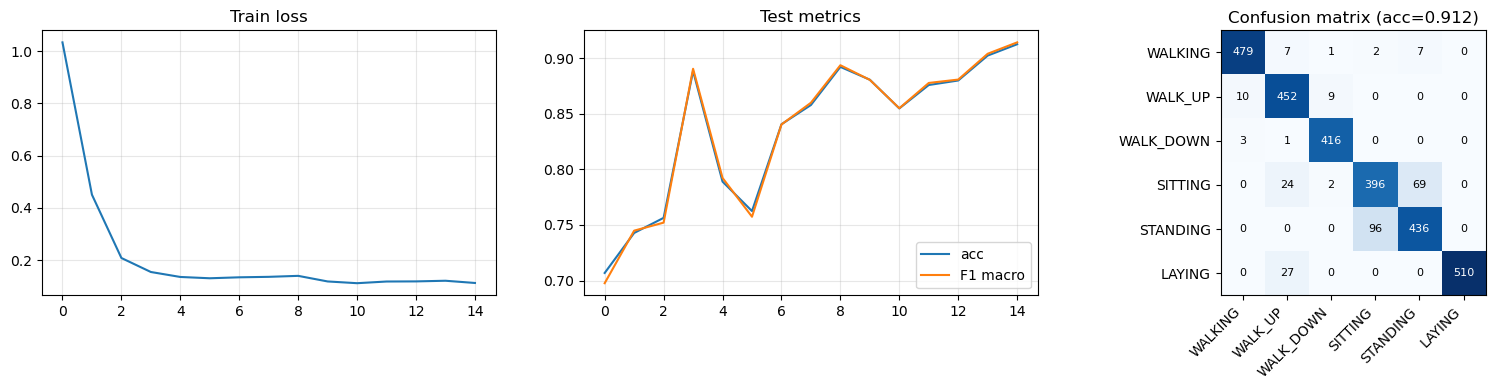

In [10]:
# Courbes d'apprentissage + matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_clf["train_loss"]); axes[0].set_title("Train loss"); axes[0].grid(alpha=0.3)
axes[1].plot(hist_clf["test_acc"], label="acc")
axes[1].plot(hist_clf["test_f1"], label="F1 macro")
axes[1].set_title("Test metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(y_true_clf, y_pred_clf)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks(range(6)); axes[2].set_xticklabels(CLASSES, rotation=45, ha="right")
axes[2].set_yticks(range(6)); axes[2].set_yticklabels(CLASSES)
for i in range(6):
    for j in range(6):
        axes[2].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
axes[2].set_title(f"Confusion matrix (acc={hist_clf['test_acc'][-1]:.3f})")
fig.tight_layout()
plt.show()


---

## Partie B — Forecasting multi-step (ETT — Electricity Transformer Temperature)

### B.1 Présentation du dataset

Le dataset **ETT** (Zhou et al., AAAI 2021) suit la température des transformateurs électriques en Chine sur 2 ans (2016-2018), avec **6 features + 1 target** :

| Colonne | Description |
|---|---|
| HUFL, HULL | High UseFul Load, High UseLess Load |
| MUFL, MULL | Middle UseFul / UseLess Load |
| LUFL, LULL | Low UseFul / UseLess Load |
| **OT** | **Oil Temperature** (target) |

Nous utilisons **ETTh1** (échantillonnage horaire, 17 420 points).

### B.2 Sliding window pour forecasting

Étant donné une fenêtre d'entrée de longueur $L$ et un horizon $H$ :

$$
\underbrace{(\mathbf{x}_{t-L+1}, \dots, \mathbf{x}_t)}_{\text{input window}} \longrightarrow \underbrace{(y_{t+1}, \dots, y_{t+H})}_{\text{forecast horizon}}
$$

Pour $L=96$ et $H=24$, le modèle prédit les **24 prochaines heures** d'OT à partir des **96 dernières heures** (4 derniers jours) de toutes les features.

### B.3 Métriques

$$
\text{MAE} = \frac{1}{N H}\sum_{n,h} |y_{n,h} - \hat y_{n,h}| \qquad
\text{RMSE} = \sqrt{\frac{1}{N H}\sum_{n,h} (y_{n,h} - \hat y_{n,h})^2} \qquad
\text{MAPE} = \frac{100}{N H} \sum_{n,h} \left|\frac{y_{n,h} - \hat y_{n,h}}{y_{n,h}}\right|
$$


In [11]:
# Téléchargement automatique ETTh1
ETT_URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
ETT_CSV = DATA_DIR / "ETTh1.csv"
if not ETT_CSV.exists():
    print(f"Téléchargement {ETT_URL} ...")
    safe_urlretrieve(ETT_URL, ETT_CSV)
print(f"  → {ETT_CSV.stat().st_size / 1e3:.1f} kB")

df_ett = pd.read_csv(ETT_CSV, parse_dates=["date"])
print(df_ett.shape)
df_ett.head()


  → 2589.7 kB
(17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


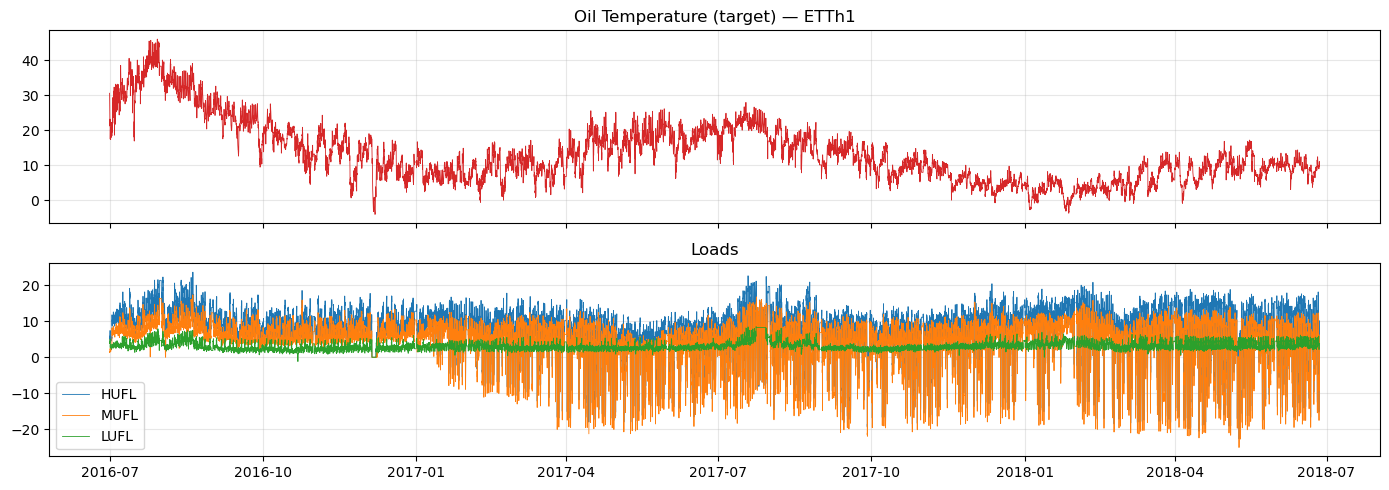

In [12]:
# Visualisation rapide
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(df_ett["date"], df_ett["OT"], color="C3", linewidth=0.6)
axes[0].set_title("Oil Temperature (target) — ETTh1"); axes[0].grid(alpha=0.3)
axes[1].plot(df_ett["date"], df_ett["HUFL"], label="HUFL", linewidth=0.6)
axes[1].plot(df_ett["date"], df_ett["MUFL"], label="MUFL", linewidth=0.6)
axes[1].plot(df_ett["date"], df_ett["LUFL"], label="LUFL", linewidth=0.6)
axes[1].set_title("Loads"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [13]:
# Préparation : split temporel (pas aléatoire !), standardisation sur train uniquement
FEATURES = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = "OT"
L, H = 96, 24                                        # input window, horizon

data = df_ett[FEATURES].values.astype(np.float32)    # [N, 7]
n = len(data)
n_train = int(0.7 * n)
n_val   = int(0.1 * n)

scaler_ett = StandardScaler().fit(data[:n_train])
data_s = scaler_ett.transform(data).astype(np.float32)

def make_windows(arr, L, H, target_col=-1):
    X, Y = [], []
    for i in range(len(arr) - L - H + 1):
        X.append(arr[i:i+L])                          # [L, n_features]
        Y.append(arr[i+L:i+L+H, target_col])          # [H]
    return np.stack(X), np.stack(Y)

X_tr, Y_tr = make_windows(data_s[:n_train],                L, H)
X_va, Y_va = make_windows(data_s[n_train:n_train+n_val],   L, H)
X_te, Y_te = make_windows(data_s[n_train+n_val:],          L, H)
print(f"Train : {X_tr.shape} → {Y_tr.shape}")
print(f"Val   : {X_va.shape} → {Y_va.shape}")
print(f"Test  : {X_te.shape} → {Y_te.shape}")

train_loader_f = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(Y_tr)),
                            batch_size=64, shuffle=True)
val_loader_f   = DataLoader(TensorDataset(torch.from_numpy(X_va), torch.from_numpy(Y_va)),
                            batch_size=256)
test_loader_f  = DataLoader(TensorDataset(torch.from_numpy(X_te), torch.from_numpy(Y_te)),
                            batch_size=256)


Train : (12075, 96, 7) → (12075, 24)
Val   : (1623, 96, 7) → (1623, 24)
Test  : (3365, 96, 7) → (3365, 24)


### B.4 Architecture GRU multi-step

```
x : [B, L=96, F=7]
      ↓ nn.GRU(input=7, hidden=128, num_layers=2)
h_T : [B, 128]
      ↓ Dropout(0.2)
      ↓ nn.Linear(128, H=24)
ŷ : [B, 24]                # forecast direct des 24 prochaines heures
```

On utilise la stratégie **direct multi-step** : on prédit les $H$ pas en un seul passage (au lieu d'autoregressive, qui accumule les erreurs).

**Loss** : MSE sur le forecast standardisé.


In [14]:
class GRUForecaster(nn.Module):
    def __init__(self, n_features=7, hidden=128, n_layers=2, horizon=24, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):                 # x : [B, L, F]
        _, h_n = self.gru(x)              # h_n : [n_layers, B, H]
        return self.head(self.drop(h_n[-1]))   # [B, horizon]

model_fc = GRUForecaster(n_features=len(FEATURES), horizon=H).to(DEVICE)
print(model_fc)
print(f"\nParamètres : {sum(p.numel() for p in model_fc.parameters()):,}")


GRUForecaster(
  (gru): GRU(7, 128, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=128, out_features=24, bias=True)
)

Paramètres : 154,776


In [15]:
def train_forecaster(model, train_loader, val_loader, epochs=15, lr=1e-3, clip=1.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.MSELoss()
    history = {"train_loss": [], "val_mse": [], "val_mae": []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for X, Y in train_loader:
            X, Y = X.to(DEVICE), Y.to(DEVICE)
            opt.zero_grad()
            Yh = model(X)
            loss = criterion(Yh, Y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            running += loss.item() * X.size(0)
        sched.step()
        train_loss = running / len(train_loader.dataset)

        model.eval()
        ys, yhs = [], []
        with torch.no_grad():
            for X, Y in val_loader:
                Yh = model(X.to(DEVICE)).cpu().numpy()
                ys.append(Y.numpy()); yhs.append(Yh)
        ys = np.concatenate(ys); yhs = np.concatenate(yhs)
        val_mse = mean_squared_error(ys.ravel(), yhs.ravel())
        val_mae = mean_absolute_error(ys.ravel(), yhs.ravel())
        history["train_loss"].append(train_loss)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)
        print(f"Ep {ep:02d} | train_loss={train_loss:.4f} | val_mse={val_mse:.4f} | val_mae={val_mae:.4f}")
    return history

hist_fc = train_forecaster(model_fc, train_loader_f, val_loader_f, epochs=15)


Ep 01 | train_loss=0.1707 | val_mse=0.1316 | val_mae=0.3117
Ep 02 | train_loss=0.1032 | val_mse=0.1051 | val_mae=0.2660
Ep 03 | train_loss=0.0973 | val_mse=0.0960 | val_mae=0.2536
Ep 04 | train_loss=0.0934 | val_mse=0.0720 | val_mae=0.2101
Ep 05 | train_loss=0.0908 | val_mse=0.0884 | val_mae=0.2402
Ep 06 | train_loss=0.0886 | val_mse=0.0836 | val_mae=0.2299
Ep 07 | train_loss=0.0858 | val_mse=0.0984 | val_mae=0.2500
Ep 08 | train_loss=0.0836 | val_mse=0.1159 | val_mae=0.2794
Ep 09 | train_loss=0.0814 | val_mse=0.0856 | val_mae=0.2271
Ep 10 | train_loss=0.0796 | val_mse=0.1078 | val_mae=0.2659
Ep 11 | train_loss=0.0782 | val_mse=0.0808 | val_mae=0.2196
Ep 12 | train_loss=0.0765 | val_mse=0.0819 | val_mae=0.2197
Ep 13 | train_loss=0.0749 | val_mse=0.0733 | val_mae=0.2080
Ep 14 | train_loss=0.0737 | val_mse=0.0832 | val_mae=0.2233
Ep 15 | train_loss=0.0737 | val_mse=0.0825 | val_mae=0.2219


TEST | MAE = 1.325 °C | RMSE = 1.826 °C | MAPE = 2497724.02 %


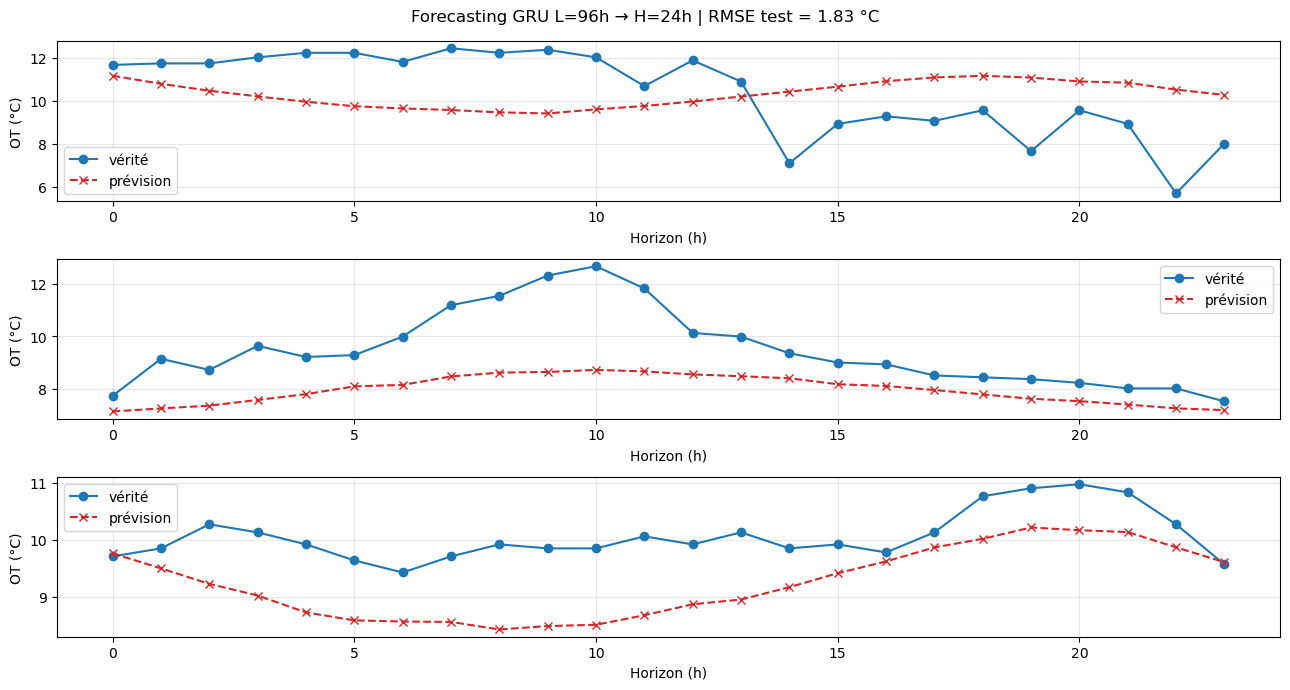

In [16]:
# Évaluation finale sur test + dé-standardisation pour métriques en °C
model_fc.eval()
ys, yhs = [], []
with torch.no_grad():
    for X, Y in test_loader_f:
        Yh = model_fc(X.to(DEVICE)).cpu().numpy()
        ys.append(Y.numpy()); yhs.append(Yh)
ys = np.concatenate(ys); yhs = np.concatenate(yhs)

# Inverse transform sur le canal OT (dernier)
mu_ot, sig_ot = scaler_ett.mean_[-1], scaler_ett.scale_[-1]
ys_unscaled  = ys  * sig_ot + mu_ot
yhs_unscaled = yhs * sig_ot + mu_ot

mae  = mean_absolute_error(ys_unscaled.ravel(), yhs_unscaled.ravel())
rmse = np.sqrt(mean_squared_error(ys_unscaled.ravel(), yhs_unscaled.ravel()))
mape = 100 * np.mean(np.abs((ys_unscaled - yhs_unscaled) / (np.abs(ys_unscaled) + 1e-6)))
print(f"TEST | MAE = {mae:.3f} °C | RMSE = {rmse:.3f} °C | MAPE = {mape:.2f} %")

# Visualisation : 3 fenêtres aléatoires
fig, axes = plt.subplots(3, 1, figsize=(13, 7))
rng = np.random.default_rng(0)
for ax, idx in zip(axes, rng.choice(len(ys), 3, replace=False)):
    ax.plot(range(H), ys_unscaled[idx],  "o-", label="vérité", color="C0")
    ax.plot(range(H), yhs_unscaled[idx], "x--", label="prévision", color="C3")
    ax.set_xlabel("Horizon (h)"); ax.set_ylabel("OT (°C)")
    ax.grid(alpha=0.3); ax.legend()
fig.suptitle(f"Forecasting GRU L={L}h → H={H}h | RMSE test = {rmse:.2f} °C")
fig.tight_layout(); plt.show()


---

## Partie C — Détection d'anomalies (AI4I 2020 Predictive Maintenance)

### C.1 Présentation du dataset

Le dataset **AI4I 2020** (Matzka, UCI 2020) simule une **machine industrielle** avec **10 000 enregistrements** et **10 features** dont 5 capteurs :

| Feature | Description |
|---|---|
| Air temperature [K] | Température ambiante |
| Process temperature [K] | Température processus |
| Rotational speed [rpm] | Vitesse rotation |
| Torque [Nm] | Couple |
| Tool wear [min] | Usure outil |
| **Machine failure** | Label binaire (anomalie) |

Le label `Machine failure` est très **déséquilibré** (~3.4 % de pannes).

### C.2 Approche : classification supervisée BiLSTM

Nous traitons la détection comme une classification binaire séquentielle. Bien que le dataset soit tabulaire, nous **simulons une fenêtre temporelle** en regroupant **W=20 enregistrements consécutifs** pour exploiter le contexte local (l'ordre des lignes représente la chronologie de production).

$$
\mathbf{x}_{1:W} \in \mathbb{R}^{W \times 5} \;\longrightarrow\; \hat y \in \{0, 1\}
$$

### C.3 Loss pondérée pour classes déséquilibrées

$$
\mathcal{L} = - \sum_{i} w_{y_i} \log p(y_i | \mathbf{x}_i), \qquad w_c = \frac{N}{2 \cdot N_c}
$$

avec $N_c$ le nombre d'exemples de la classe $c$ (poids inverse à la fréquence). En PyTorch : `nn.CrossEntropyLoss(weight=class_weights)`.

### C.4 Métriques pour datasets déséquilibrés

Accuracy est trompeuse → on privilégie :
- **AUC-ROC** : aire sous TPR = f(FPR)
- **F1** sur la classe positive
- **Precision/Recall** par classe


In [17]:
# Téléchargement AI4I 2020
AI4I_URL = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
AI4I_DIR = DATA_DIR / "AI4I2020"
AI4I_CSV = AI4I_DIR / "ai4i2020.csv"

if not AI4I_CSV.exists():
    AI4I_DIR.mkdir(exist_ok=True)
    zip_path = AI4I_DIR / "ai4i.zip"
    print(f"Téléchargement {AI4I_URL} ...")
    safe_urlretrieve(AI4I_URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(AI4I_DIR)
    zip_path.unlink()
print(f"  → {AI4I_CSV.stat().st_size / 1e3:.1f} kB")

df_ai4i = pd.read_csv(AI4I_CSV)
print(df_ai4i.shape)
df_ai4i.head()


Téléchargement https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip ...
  ⚠️  SSL vérifié a échoué (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1010)>)
      → fallback sur contexte non vérifié.
  → 522.0 kB
(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [18]:
# Vérification du déséquilibre + features choisies
print("Distribution Machine failure :")
print(df_ai4i["Machine failure"].value_counts(normalize=True).round(4))

SENSORS = ["Air temperature [K]", "Process temperature [K]",
           "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

X_raw = df_ai4i[SENSORS].values.astype(np.float32)
y_raw = df_ai4i["Machine failure"].values.astype(np.int64)
print(f"X_raw : {X_raw.shape}, y_raw : {y_raw.shape}")


Distribution Machine failure :
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64
X_raw : (10000, 5), y_raw : (10000,)


In [19]:
# Construction des fenêtres glissantes de longueur W
W = 20
def windowize(X, y, W):
    Xs, ys = [], []
    for i in range(len(X) - W + 1):
        Xs.append(X[i:i+W])
        # Une fenêtre est anormale si AU MOINS UNE de ses lignes est anormale
        ys.append(int(y[i:i+W].max()))
    return np.stack(Xs).astype(np.float32), np.array(ys, dtype=np.int64)

# Split temporel 70/15/15 AVANT fenêtrage (pour éviter la fuite)
n = len(X_raw)
n_tr, n_va = int(0.7 * n), int(0.15 * n)
X_tr_raw, y_tr_raw = X_raw[:n_tr],            y_raw[:n_tr]
X_va_raw, y_va_raw = X_raw[n_tr:n_tr+n_va],   y_raw[n_tr:n_tr+n_va]
X_te_raw, y_te_raw = X_raw[n_tr+n_va:],       y_raw[n_tr+n_va:]

scaler_ai = StandardScaler().fit(X_tr_raw)
X_tr_s = scaler_ai.transform(X_tr_raw).astype(np.float32)
X_va_s = scaler_ai.transform(X_va_raw).astype(np.float32)
X_te_s = scaler_ai.transform(X_te_raw).astype(np.float32)

X_tr_w, y_tr_w = windowize(X_tr_s, y_tr_raw, W)
X_va_w, y_va_w = windowize(X_va_s, y_va_raw, W)
X_te_w, y_te_w = windowize(X_te_s, y_te_raw, W)
print(f"Train : {X_tr_w.shape} | pos ratio = {y_tr_w.mean():.3f}")
print(f"Val   : {X_va_w.shape} | pos ratio = {y_va_w.mean():.3f}")
print(f"Test  : {X_te_w.shape} | pos ratio = {y_te_w.mean():.3f}")


Train : (6981, 20, 5) | pos ratio = 0.447
Val   : (1481, 20, 5) | pos ratio = 0.335
Test  : (1481, 20, 5) | pos ratio = 0.244


### C.5 Architecture BiLSTM pour détection

```
x : [B, W=20, C=5]
      ↓ nn.LSTM(input=5, hidden=64, num_layers=1, bidirectional=True)
h_T : [B, 128]                                  # 64 forward + 64 backward concaténés
      ↓ Dropout(0.4) — fort car classes déséquilibrées
      ↓ nn.Linear(128, 2)
logits : [B, 2]
```


In [20]:
class AnomalyBiLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=64, n_layers=1, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=n_layers, bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden, 2)

    def forward(self, x):                          # [B, W, C]
        _, (h_n, _) = self.lstm(x)                 # h_n : [2*n_layers, B, H]
        # Concat dernier état forward (h_n[-2]) et backward (h_n[-1])
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)   # [B, 2H]
        return self.fc(self.drop(h_cat))

model_ad = AnomalyBiLSTM().to(DEVICE)
print(model_ad)
print(f"\nParamètres : {sum(p.numel() for p in model_ad.parameters()):,}")


AnomalyBiLSTM(
  (lstm): LSTM(5, 64, batch_first=True, bidirectional=True)
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Paramètres : 36,610


In [21]:
# Class weights pour gérer le déséquilibre
n0 = int((y_tr_w == 0).sum()); n1 = int((y_tr_w == 1).sum())
weights = torch.tensor([len(y_tr_w)/(2*n0), len(y_tr_w)/(2*n1)],
                       dtype=torch.float32, device=DEVICE)
print(f"Class weights : neg={weights[0]:.3f}, pos={weights[1]:.3f}")

train_loader_a = DataLoader(TensorDataset(torch.from_numpy(X_tr_w), torch.from_numpy(y_tr_w)),
                            batch_size=128, shuffle=True)
val_loader_a   = DataLoader(TensorDataset(torch.from_numpy(X_va_w), torch.from_numpy(y_va_w)),
                            batch_size=256)
test_loader_a  = DataLoader(TensorDataset(torch.from_numpy(X_te_w), torch.from_numpy(y_te_w)),
                            batch_size=256)


Class weights : neg=0.904, pos=1.119


In [22]:
def train_anomaly(model, train_loader, val_loader, weights, epochs=20, lr=1e-3, clip=1.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights)
    history = {"train_loss": [], "val_auc": [], "val_f1": []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            running += loss.item() * X.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        ys, ps, yh = [], [], []
        with torch.no_grad():
            for X, y in val_loader:
                logits = model(X.to(DEVICE))
                p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                ys.extend(y.numpy()); ps.extend(p); yh.extend(logits.argmax(1).cpu().numpy())
        auc = roc_auc_score(ys, ps) if len(set(ys)) > 1 else float("nan")
        f1  = f1_score(ys, yh)
        history["train_loss"].append(train_loss)
        history["val_auc"].append(auc); history["val_f1"].append(f1)
        print(f"Ep {ep:02d} | train_loss={train_loss:.4f} | val_AUC={auc:.4f} | val_F1={f1:.4f}")
    return history

hist_ad = train_anomaly(model_ad, train_loader_a, val_loader_a, weights, epochs=20)


Ep 01 | train_loss=0.6411 | val_AUC=0.7369 | val_F1=0.5998
Ep 02 | train_loss=0.5399 | val_AUC=0.7576 | val_F1=0.4075
Ep 03 | train_loss=0.4908 | val_AUC=0.7880 | val_F1=0.4576
Ep 04 | train_loss=0.4734 | val_AUC=0.8110 | val_F1=0.5888
Ep 05 | train_loss=0.4525 | val_AUC=0.8336 | val_F1=0.6239
Ep 06 | train_loss=0.4398 | val_AUC=0.8413 | val_F1=0.6475
Ep 07 | train_loss=0.4241 | val_AUC=0.8475 | val_F1=0.6776
Ep 08 | train_loss=0.4207 | val_AUC=0.8430 | val_F1=0.6621
Ep 09 | train_loss=0.3965 | val_AUC=0.8534 | val_F1=0.6869
Ep 10 | train_loss=0.3887 | val_AUC=0.8380 | val_F1=0.6778
Ep 11 | train_loss=0.3723 | val_AUC=0.8478 | val_F1=0.6893
Ep 12 | train_loss=0.3530 | val_AUC=0.8628 | val_F1=0.7117
Ep 13 | train_loss=0.3368 | val_AUC=0.8607 | val_F1=0.7014
Ep 14 | train_loss=0.3151 | val_AUC=0.8583 | val_F1=0.6951
Ep 15 | train_loss=0.2985 | val_AUC=0.8370 | val_F1=0.6850
Ep 16 | train_loss=0.2925 | val_AUC=0.8463 | val_F1=0.7041
Ep 17 | train_loss=0.2821 | val_AUC=0.8094 | val_F1=0.68

TEST | AUC-ROC = 0.8351 | Precision = 0.5179 | Recall = 0.7618 | F1 = 0.6166


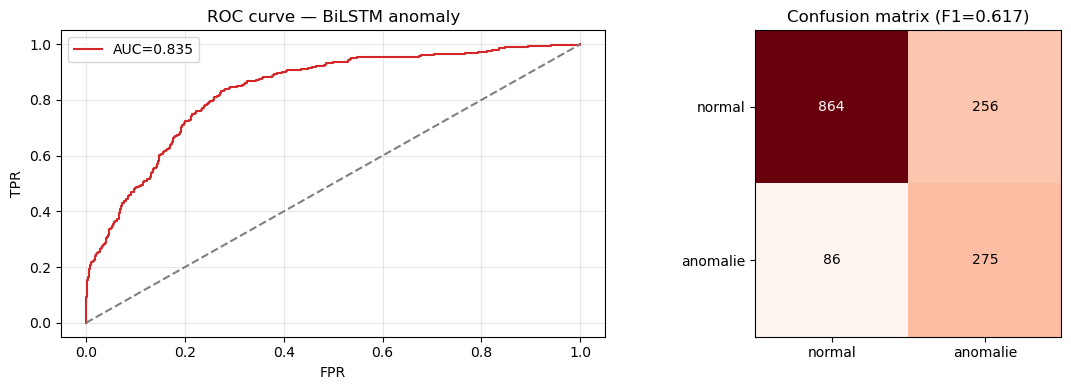

In [23]:
# Évaluation finale sur le test set
model_ad.eval()
ys, ps, yh = [], [], []
with torch.no_grad():
    for X, y in test_loader_a:
        logits = model_ad(X.to(DEVICE))
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        ys.extend(y.numpy()); ps.extend(p); yh.extend(logits.argmax(1).cpu().numpy())

auc = roc_auc_score(ys, ps)
prec, rec, f1, _ = precision_recall_fscore_support(ys, yh, average="binary")
print(f"TEST | AUC-ROC = {auc:.4f} | Precision = {prec:.4f} | Recall = {rec:.4f} | F1 = {f1:.4f}")

# Courbe ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(ys, ps)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color="C3", label=f"AUC={auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve — BiLSTM anomaly"); axes[0].legend(); axes[0].grid(alpha=0.3)

cm = confusion_matrix(ys, yh)
im = axes[1].imshow(cm, cmap="Reds")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["normal", "anomalie"])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["normal", "anomalie"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
axes[1].set_title(f"Confusion matrix (F1={f1:.3f})")
fig.tight_layout(); plt.show()


---

## Partie D — Synthèse

### D.1 Résumé des 3 tâches

| Axe | Dataset | Architecture | Métriques | Particularité |
|---|---|---|---|---|
| Classification | UCI HAR (6 classes) | LSTM 2 couches → Linear | Accuracy, F1 macro | `h_n[-1]` comme résumé séquence |
| Forecasting | ETTh1 (OT, L=96 → H=24) | GRU 2 couches → Linear(24) | MAE, RMSE, MAPE | Multi-step direct |
| Détection d'anomalies | AI4I 2020 (binaire) | BiLSTM 1 couche → Linear(2) | AUC-ROC, F1 | Class weights, fenêtres W=20 |

### D.2 Mapping concept ↔ API PyTorch

| Concept | API PyTorch |
|---|---|
| RNN vanille | `nn.RNN(input_size, hidden_size, num_layers, batch_first=True)` |
| LSTM | `nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)` |
| GRU | `nn.GRU(input_size, hidden_size, num_layers, batch_first=True)` |
| Bidirectionnel | `bidirectional=True` (sortie de dim `2 * hidden_size`) |
| Dropout entre couches | `dropout=p` (n'agit que si `num_layers > 1`) |
| Gradient clipping | `torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)` |
| Séquences variables | `nn.utils.rnn.pack_padded_sequence` / `pad_packed_sequence` |
| Class weights | `nn.CrossEntropyLoss(weight=tensor)` |
| LR scheduler | `torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N)` |

### D.3 Recommandations pratiques

1. **`batch_first=True`** systématiquement — plus lisible et compatible avec la plupart des DataLoaders
2. **Normaliser** les features par canal (StandardScaler) — un RNN converge mal sans
3. **Split temporel**, pas aléatoire, pour les séries temporelles — éviter la fuite de données futures dans le train
4. **Gradient clipping à 1.0** par défaut — pratique standard sur les RNN
5. **`dropout`** n'est appliqué **qu'entre** les couches RNN (pas après la dernière) — penser à un `nn.Dropout` explicite sur la sortie
6. **Préférer LSTM** pour les séquences > 100 pas, **GRU** sinon (plus rapide, ~25 % moins de params)
7. Pour le **forecasting**, la stratégie **direct multi-step** évite l'accumulation d'erreur des approches autoregressives

### D.4 Pour aller plus loin

- **Transformers temporels** : Informer, Autoformer, FEDformer (état de l'art sur ETT depuis 2021)
- **Architectures hybrides** : CNN 1D + LSTM pour des features locales + globales
- **Unsupervised anomaly** : Autoencoder LSTM (étudié en Module 3)
- **Quantile regression** : prédire des intervalles de confiance au lieu de points

---

*Fin du TP — Module 2 / RNN-LSTM-GRU séries temporelles*
